# 0. Preambule

## Présentation de sujet

Le projet est un hackathon dont le but est de réaliser une régression permettant de prédire les valeurs manquante pour former de courbe .
Ces courbes sont de courbes de consommation électriques fournies par Enedis pour le hackathon .

### Import des librairies

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import QuantileRegressor


### Chargement des dataframes

In [5]:
Data_xtest = pd.read_csv('X_test.csv')
Data_xtrain = pd.read_csv('X_train.csv')
Data_ytrain = pd.read_csv('y_train.csv')
Data_output = pd.read_csv('new_output_sample.csv')

df_xtest = pd.DataFrame(data = Data_xtest)
df_xtrain = pd.DataFrame(data = Data_xtrain)
df_ytrain = pd.DataFrame(data = Data_ytrain)
df_output = pd.DataFrame(data = Data_output)

Affichage des dataframes

In [ ]:
print("xtest")
print(df_xtest.head())
print("xtrain")
print(df_xtrain.head())
print("ytrain")
print(df_ytrain.head())
print("output")
print(df_output.head())

xtest
              Horodate  123476859  123596487  123798654  123875946  123879645  \
0  2023-01-09 00:00:00      102.0      992.0      365.0      252.0       71.0   
1  2023-01-09 00:30:00       89.0      996.0      351.0      219.0       47.0   
2  2023-01-09 01:00:00      134.0      841.0      314.0      213.0       55.0   
3  2023-01-09 01:30:00      130.0      961.0      228.0      253.0       35.0   
4  2023-01-09 02:00:00      135.0      949.0      213.0      243.0       47.0   

   123897645  123947865  124367958  124568973  ...  holed_991  holed_992  \
0      132.0       30.0      201.0      121.0  ...       38.0      168.0   
1      140.0       31.0      173.0      186.0  ...       27.0       82.0   
2      114.0       38.0      204.0      251.0  ...       37.0      102.0   
3      103.0       35.0      176.0      305.0  ...       13.0       78.0   
4      472.0       21.0      187.0      283.0  ...       62.0      107.0   

   holed_993  holed_994  holed_995  holed_996  hol

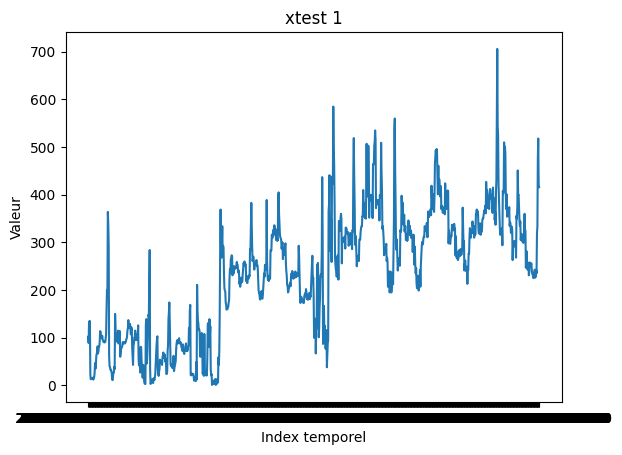

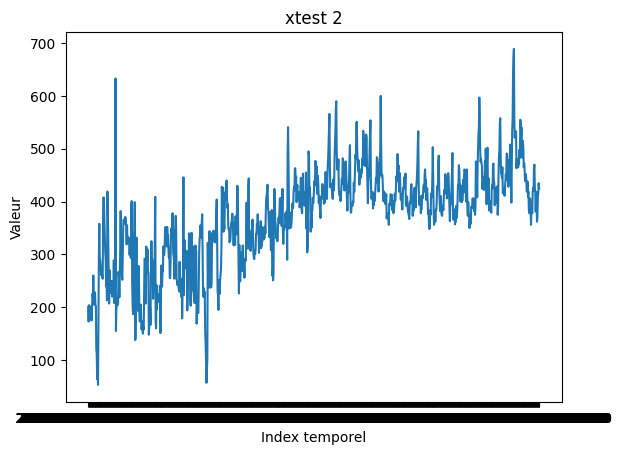

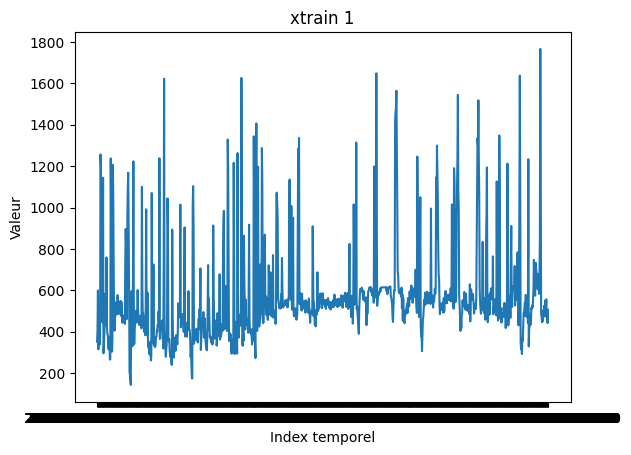

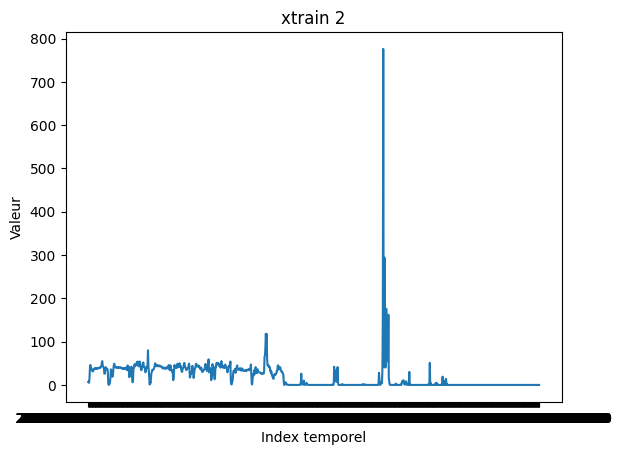

In [8]:
Xaxis = df_xtest['Horodate']
Yaxis_display = df_xtest['123476859']

plt.plot(Xaxis, Yaxis_display)
plt.title('xtest 1')
plt.xlabel('Index temporel')
plt.ylabel('Valeur')
plt.show()

Xaxis = df_xtest['Horodate']
Yaxis_display = df_xtest['124367958']

plt.plot(Xaxis, Yaxis_display)
plt.title('xtest 2')
plt.xlabel('Index temporel')
plt.ylabel('Valeur')
plt.show()

Xaxis = df_xtrain['Horodate']
Yaxis_display = df_xtrain['5423908671']

plt.plot(Xaxis, Yaxis_display)
plt.title('xtrain 1')
plt.xlabel('Index temporel')
plt.ylabel('Valeur')
plt.show()

Xaxis = df_xtrain['Horodate']
Yaxis_display = df_xtrain['218753964']

plt.plot(Xaxis, Yaxis_display)
plt.title('xtrain 2')
plt.xlabel('Index temporel')
plt.ylabel('Valeur')
plt.show()

# 1. Prise en main du benchmark et de la MAE

## 1.1 Test d'affichage sans et avec interpolation lineaire

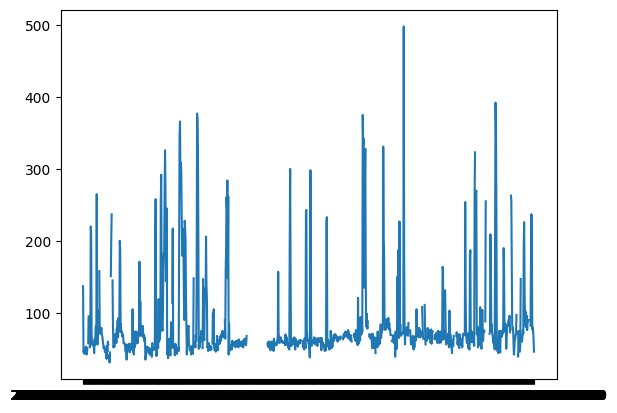

In [21]:
Yaxis_holed500 = df_xtrain['holed_500']

plt.plot(Xaxis, Yaxis_holed500)
plt.show()

Dans cet affichage d'une courbe holed du dataframe xtrain, on remarque effectivement les valeurs manquantes

Importons maintenant la fonction d'interpolation de benchmark donne par les createurs du challenge

In [22]:
def fill_nan_with_interpolation(column):
    col = column.copy()
    col = col.interpolate(method='linear', limit_direction='both')
    return col

Essayons maintenant de completer cette derniere courbe holed avec l'interpolation du benchmark

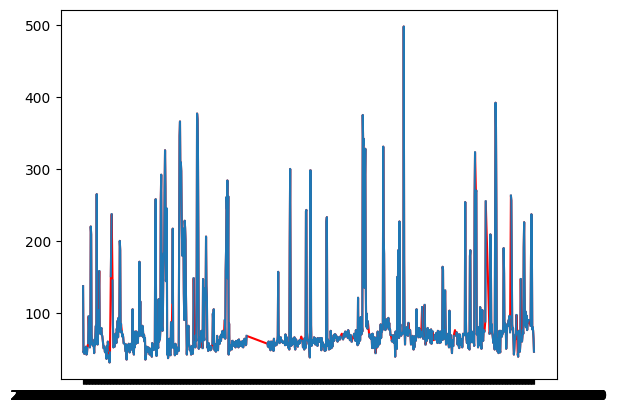

In [23]:
Yaxis_filled500 = fill_nan_with_interpolation(Yaxis_holed500)

plt.plot(Xaxis, Yaxis_filled500, 'r')
plt.plot(Xaxis, Yaxis_holed500)
plt.show()

Comme dit dans la presentation du benchmark, cette interpolation lineaire relie le dernier point connu avec le prochain point connu par une ligne droite.

En creant un fichier y_test en utilisant uniquement cette fonction d'interpolation, le score obtenu devrait etre celui du benchmark (~107).

Avant cela, essayons de faire de meme pour x_train afin de pouvoir calculer une MAE grace a y_train qui est donne.

Il nous faut completer les 1000 dernieres colonnes du dataframe x_train

In [24]:
Y_holed = []
Y_train_filled = []
Y_holed_text_format = ''

# On ajoute toutes les courbes holed dans un tableau
for i in range(1,1001):
    Y_holed_text_format = "holed_{}".format(i)
    Y_holed.append(df_xtrain[Y_holed_text_format])

# On applique l'interpolation du benchmark a toutes les courbes holed
for i in range(1000):
    Y_filled = fill_nan_with_interpolation(Y_holed[i])
    Y_train_filled.append(Y_filled)

## 1.2 Calcul de la MAE

On peut maintenant calculer la MAE pour chaque pair de courbes

Voici un exemple pour holed_1

In [25]:
# De la meme manieres que Y_holed, creons un tableau pour les y_train
Y_train = []
for i in range(1,1001):
    Y_train_text_format = "holed_{}".format(i)
    Y_train.append(df_ytrain[Y_train_text_format])

mae = mean_absolute_error(Y_train[0], Y_train_filled[0])
print(mae)

29.211141145199807


### 1.2.1 Probleme sur df_ytrain['holed_192']

Calculons alors une moyenne de MAE pour toutes les courbes 

Pour avoir la MAE generale, on prend la moyenne des MAE pour toutes les courbes

In [26]:
mean_mae = 0

for i in range(1000):
    mean_mae += mean_absolute_error(Y_train[i], Y_train_filled[i])
mean_mae /= 1000

print("MAE moyenne des 1000 courbes holed d'entrainement: ", mean_mae)

ValueError: Input contains NaN.

On remarque qu'une courbe contient des NaN ce qui pose probleme dans le calcul de la MAE, car il y a une erreur lors de l'exécution, qui est ValueError : Input contains NaN.

In [27]:
coupable = 191

# On vérifie si on a effectivement des valeurs nan
nanValIndex = []
nanVal = False

for i in range(len(Y_train[coupable])):
    if (np.isnan(Y_train[coupable][i])):
        nanVal = True
        print("Nan dans Y_train a l'index ", i)
    elif (np.isnan(Y_train_filled[coupable][i])):
        print("Nan dans Y_train_filled a l'index ", i)
if (not(nanVal)):
    print("apparement pas de soucis")

Nan dans Y_train a l'index  0
Nan dans Y_train a l'index  1
Nan dans Y_train a l'index  2
Nan dans Y_train a l'index  3
Nan dans Y_train a l'index  4
Nan dans Y_train a l'index  5
Nan dans Y_train a l'index  6
Nan dans Y_train a l'index  7
Nan dans Y_train a l'index  8
Nan dans Y_train a l'index  9
Nan dans Y_train a l'index  10
Nan dans Y_train a l'index  11
Nan dans Y_train a l'index  12
Nan dans Y_train a l'index  13
Nan dans Y_train a l'index  14
Nan dans Y_train a l'index  15
Nan dans Y_train a l'index  16
Nan dans Y_train a l'index  17
Nan dans Y_train a l'index  18
Nan dans Y_train a l'index  19
Nan dans Y_train a l'index  20
Nan dans Y_train a l'index  21
Nan dans Y_train a l'index  22
Nan dans Y_train a l'index  23
Nan dans Y_train a l'index  24
Nan dans Y_train a l'index  25
Nan dans Y_train a l'index  26
Nan dans Y_train a l'index  27
Nan dans Y_train a l'index  28
Nan dans Y_train a l'index  29
Nan dans Y_train a l'index  30
Nan dans Y_train a l'index  31
Nan dans Y_train a

In [28]:
print("ytrain")
print(df_ytrain['holed_192'])
print(Y_train[191]) # fichier donne par le challenge

# Clean affichage
print("\n\n")

# Verifions si 191 est vraiment ENTIEREMENT NaN ou bien s'il y a une valeur a un moment
for i in range(len(Y_train[191])):
    if (not np.isnan(Y_train[191][i])):
        print("Il y a la valeur ", Y_train[191][i], " a l'indice ", i)

ytrain
0      NaN
1      NaN
2      NaN
3      NaN
4      NaN
        ..
1052   NaN
1053   NaN
1054   NaN
1055   NaN
1056   NaN
Name: holed_192, Length: 1057, dtype: float64
0      NaN
1      NaN
2      NaN
3      NaN
4      NaN
        ..
1052   NaN
1053   NaN
1054   NaN
1055   NaN
1056   NaN
Name: holed_192, Length: 1057, dtype: float64



Il y a la valeur  0.0  a l'indice  199


On repere que les Nan se trouvent dans la courbe #192 soit, Y_train[191]

NB: la seule valeur non NaN de Y_train[191] est un "0" a l'indice 199.

Comme cela parait etre un probleme des donnees que nous avons telecharge du site, nous decidons de simplement ignorer cette courbe ci.

In [29]:
Y_train.pop(191)
Y_train_filled.pop(191)

0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
1052    0.0
1053    0.0
1054    0.0
1055    0.0
1056    0.0
Name: holed_192, Length: 1057, dtype: float64

In [30]:
mean_mae = 0

# TOFIX: apparement il y a des NaN valeurs dans 191
for i in range(len(Y_train)):
    mean_mae += mean_absolute_error(Y_train[i], Y_train_filled[i])
mean_mae /= len(Y_train)

print("MAE moyenne des 1000 courbes holed d'entrainement: ", mean_mae)

MAE moyenne des 1000 courbes holed d'entrainement:  12.440741224800595


Nous voyons que cette supression de Y_train[191] et son interpolation associee a effectivement règlé le soucis.

## 1.3 Utilisation du benchmark sur df_xtest

Maintenant que nous avons vu comment utiliser la fonction de benchmark sur nos donnees d'entrainement, nous allons l'utiliser sur X_test afin de creer un Y_test associe.

Nous convertirons celui-ci en .csv afin de le charger sur le site du challenge pour verifier notre score.

Creons d'abord un tableau contenant les 1000 courbes holed de X_test

In [31]:
X_test_holed = []
for i in range(1,1001):
    X_test_text_format = "holed_{}".format(i)
    X_test_holed.append(df_xtest[X_test_text_format])

Creons maintenant notre tableau Y_test et remplissons le des courbes remplies par interpolation lineaires.

In [32]:
Y_test = []

for i in range(len(X_test_holed)):
    Y_test.append(fill_nan_with_interpolation(X_test_holed[i]))

Il nous faut maintenant convertir ce tableau en dataframe panda afin de pouvoir convertir celui-ci en .csv.

Nous devons respecter le meme format que les csv donnees.

In [33]:
data = {
    'Horodate' : df_output['Horodate']
}

for i in range(1,1001):
    text_format = f"holed_{i}"
    data[text_format] = Y_test[i-1]

df_ytest = pd.DataFrame(data)

On peut maintenant exporter notre resultat en .csv.

In [34]:
df_ytest.to_csv("Y_test.csv", index = False)

Apres avoir soummis ce fichier nous obtenons le score de 104,5369 qui est le meme score obtenu par le benchmark.

# 2. Amelioration du modele

## 2.1 Regression lineaire avec un seul modele

La regression lineaire utilisera les points voisins afin de predire une bonne valeur, pour cela il faut lui donner une fenetre dans laquelle regarder.

In [35]:
WINDOW_SIZE = 72

On definit ensuite notre fonction qui va construire les features (input) et les targets (output) de notre modele.

In [36]:
def build_features(df_x, df_y=None, window=WINDOW_SIZE):
    X_samples, y_samples = [], []
    meta = []  # pour retrouver quelle courbe / quel index reconstruire en inférence
 
    for col_idx in range(1, 1001):
        col_name = f"holed_{col_idx}"
        if col_name not in df_x.columns:
            continue
 
        series = df_x[col_name].values.astype(np.float64)
        nan_mask = np.isnan(series)
        nan_indices = np.where(nan_mask)[0]
 
        if len(nan_indices) == 0:
            continue
 
        # Remplace les NaN par interpolation linéaire pour avoir un contexte propre
        series_interp = pd.Series(series).interpolate(method='linear', limit_direction='both').values
 
        for idx in nan_indices:
            # Contexte gauche (window points avant)
            left  = series_interp[max(0, idx - window):idx]
            left  = np.pad(left, (window - len(left), 0), constant_values=0)
 
            # Contexte droit (window points après)
            right = series_interp[idx + 1:idx + 1 + window]
            right = np.pad(right, (0, window - len(right)), constant_values=0)
 
            features = np.concatenate([left, right])  # shape: (2 * window,)
            X_samples.append(features)
            meta.append((col_name, idx))
 
            if df_y is not None and col_name in df_y.columns:
                target = df_y[col_name].values[idx]
                y_samples.append(target)
 
    X = np.array(X_samples, dtype=np.float64)
    y = np.array(y_samples, dtype=np.float64) if y_samples else None
    return X, y, meta

### 2.1.1 Utilisation et evaluation du modele sur X_train

On construit donc les features en utilisant la fonction build_features

In [37]:
X_train, y_train, _ = build_features(df_xtrain, df_ytrain)

On supprime automatiquement les lignes ou la target est un NaN (comme la 192 d'avant)

In [38]:
valid = ~np.isnan(y_train)
X_train = X_train[valid]
y_train = y_train[valid]

Maintenant il faut entrainer le modele.
Donc, on utilise la fonction LinearRegression de la librairie sklearn.linear_model pour créer le modèle, puis on utilise fit pour entrainer le modème avec nos données (X_train et y_train).

In [ ]:
from sklearn.linear_model import LinearRegression
model = QuantileRegressor(quantile=0.5)
model.fit(X_train, y_train)

On utilise enfin le modele sur X_train afin de prédire les valeurs manquantes. Puis on calcule la MAE pour évaluer le modèle créé.

In [ ]:
y_pred_train = model.predict(X_train)
mae = mean_absolute_error(y_train, y_pred_train)
print(f"  → MAE sur train : {mae:.4f}  (benchmark : ~104.5)")

  → MAE sur train : 93.0099  (benchmark : ~104.5)


On trace les courbes pour visualiser le résultat pour holed_1.

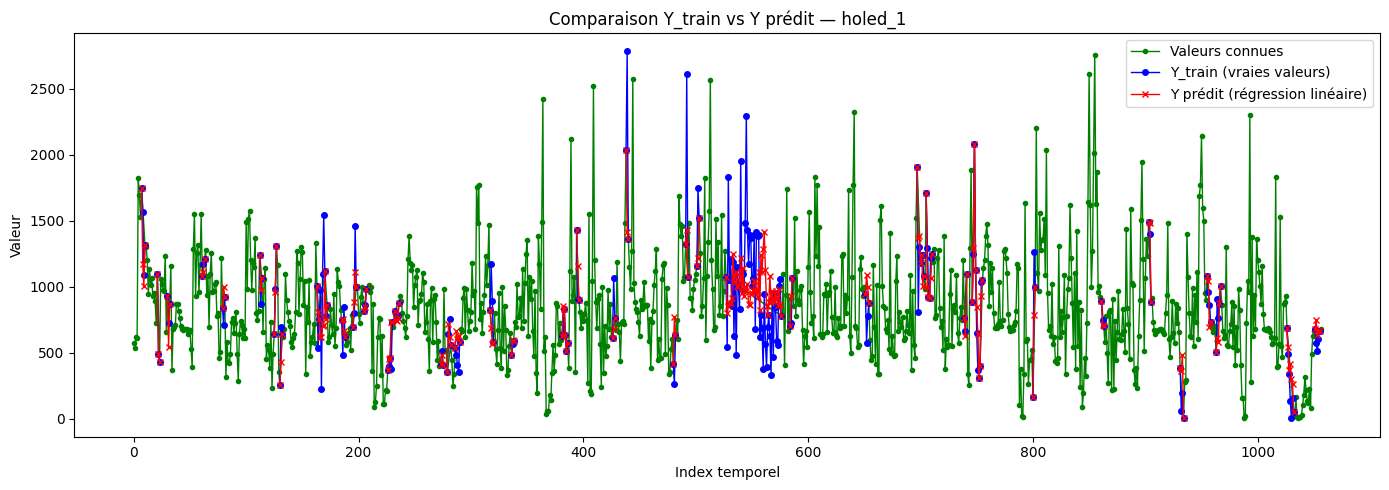

In [ ]:
col_name = "holed_1"

series_orig = df_xtrain[col_name].values.astype(np.float64)
nan_mask = np.isnan(series_orig)
nan_indices = np.where(nan_mask)[0]
known_indices = np.where(~nan_mask)[0]

y_true_col = df_ytrain[col_name].values.astype(np.float64)

indices_holed1_valid = [i for i, (c, _) in enumerate(meta_full) if c == col_name and valid_mask[i]]
nan_positions = np.array([meta_full[i][1] for i in indices_holed1_valid])
y_pred_positions = y_pred_train[indices_holed1_valid]
y_true_positions = y_true_col[nan_positions]

# Reconstruit les séries complètes pour pred et true (NaN là où on a des valeurs connues)
n = len(series_orig)
y_pred_full = np.full(n, np.nan)
y_true_full = np.full(n, np.nan)

for pos, yp, yt in zip(nan_positions, y_pred_positions, y_true_positions):
    y_pred_full[pos] = yp
    y_true_full[pos] = yt

# Ajoute les points connus aux bordures des zones NaN pour raccrocher les lignes
for idx in known_indices:
    if idx > 0 and nan_mask[idx - 1]:
        y_pred_full[idx] = series_orig[idx]
        y_true_full[idx] = series_orig[idx]
    if idx < n - 1 and nan_mask[idx + 1]:
        y_pred_full[idx] = series_orig[idx]
        y_true_full[idx] = series_orig[idx]

x_axis = np.arange(n)

plt.figure(figsize=(14, 5))

plt.plot(known_indices, series_orig[known_indices], 'o-', color='green', markersize=3, linewidth=1, label='Valeurs connues')
plt.plot(x_axis, y_true_full, 'o-', color='blue', markersize=4, linewidth=1, label='Y_train (vraies valeurs)')
plt.plot(x_axis, y_pred_full, 'x-', color='red', markersize=4, linewidth=1, label='Y prédit (régression linéaire)')

plt.title(f'Comparaison Y_train vs Y prédit — {col_name}')
plt.xlabel('Index temporel')
plt.ylabel('Valeur')
plt.legend()
plt.tight_layout()
plt.show()

### 2.1.2 Utilisation du modele sur X_test

Nous refaisons les meme manipulations sur nos valeurs X_test.

In [ ]:
X_test_feats, _, test_meta = build_features(df_xtest, df_y=None)

In [ ]:
predictions = model.predict(X_test_feats)

On recupere le resultat en remplacant les valeurs NaN de X_test par nos predictions.

In [ ]:
# Les valeurs deja connues viennent de X_test, les NaN sont remplaces par nos prédictions
result = {}
for col_idx in range(1, 1001):
    col_name = f"holed_{col_idx}"
    if col_name in df_xtest.columns:
        result[col_name] = df_xtest[col_name].values.copy()
 
for i, (col_name, idx) in enumerate(test_meta):
    result[col_name][idx] = predictions[i]

Comme pour le benchmark, on convertit nos resultats en dataframe et on export en .csv.

In [ ]:
data_out = {"Horodate": df_output["Horodate"]}
for col_idx in range(1, 1001):
    col_name = f"holed_{col_idx}"
    if col_name in result:
        data_out[col_name] = result[col_name]
 
df_ytest = pd.DataFrame(data_out)
df_ytest.to_csv("Y_test_linear.csv", index=False)

## 2.2 Regression lineaire multi-modele

### 2.2.1 Preparations des donnees

Pour partir d'un endroit propre et controle, nous re-chargons les donnees des .csv. Et nous separons les colonnes completes (features) des colonnes holed_x (targets).

In [ ]:
df_xtrain = pd.read_csv("X_train.csv")
df_ytrain = pd.read_csv("y_train.csv")
df_xtest  = pd.read_csv("X_test.csv")
df_output = pd.read_csv("new_output_sample.csv")
 
df_xtest.columns = df_xtest.columns.astype(str)
 
holed_cols    = [c for c in df_xtest.columns if c.startswith("holed_")]
features_cols = [c for c in df_xtest.columns if c not in holed_cols and c != "Horodate"]

### 2.2.2 Préparation des features

On remplace maintenant les valeurs NaN de X_test par sa medianne, car pour une distribution asymétrique des valeurs, la médianne est plus représentative des données que la moyenne.

In [ ]:
median_features   = df_xtest[features_cols].median()
X_features_filled = df_xtest[features_cols].fillna(median_features)

### 2.2.3 Regression

Pour la regression on fait:
- Dans un premier temps, l'entrainement sur les lignes ou holed_x est connue
- Puis l'inference sur les lignes ou holed_x = NaN

In [ ]:
result = df_xtest[holed_cols].copy()
 
for i, col in enumerate(holed_cols, 1):
    mask_known = ~df_xtest[col].isna()
    n_known    = int(mask_known.sum())
 
    if n_known == 0:
        # Aucune valeur connue → rempli par 0
        result[col] = result[col].fillna(0)
        print(f"[{i}/{len(holed_cols)}] {col}: rempli par 0 (aucune valeur connue)")
        continue
 
    elif n_known < 10:
        # Trop peu de valeurs → rempli par la moyenne
        mean_val    = df_xtest.loc[mask_known, col].mean()
        result[col] = result[col].fillna(mean_val)
        print(f"[{i}/{len(holed_cols)}] {col}: rempli par la moyenne (n_known={n_known})")
        continue
 
    # Régression
    X_train = X_features_filled.loc[mask_known]
    y_train = df_xtest.loc[mask_known, col]
 
    reg = LinearRegression()
    reg.fit(X_train.values, y_train.values)
 
    mask_nan = df_xtest[col].isna()
    if mask_nan.sum() > 0:
        y_pred          = reg.predict(X_features_filled.loc[mask_nan].values)
        result.loc[mask_nan, col] = y_pred

Le temps d'exécution est très long, car il faut entraîner le modèle sur plus de données .    
Le temps d'exécution est : 1h57 .

Puis on remplace les valeurs negatives qui sont des valeurs aberrantes par une interpolation.

In [ ]:
for col in holed_cols:
    result[col] = result[col].where(result[col] >= 0, np.nan)
 
result = result.apply(fill_nan_with_interpolation, axis=0)

### 2.2.4 Export de Y_test

In [ ]:
df_ytest = pd.concat([df_output[["Horodate"]], result], axis=1)
print(df_ytest.head())

              Horodate      holed_1    holed_2     holed_3  holed_4  \
0  2023-01-09 00:00:00  1061.000000  48.489427  102.821752     20.0   
1  2023-01-09 00:30:00  1041.000000  75.103172   99.000000     42.0   
2  2023-01-09 01:00:00   995.000000  60.463385  105.000000     19.0   
3  2023-01-09 01:30:00   998.000000  67.785244   98.771749     34.0   
4  2023-01-09 02:00:00   974.747217  53.993385  107.000000     21.0   

      holed_5  holed_6  holed_7  holed_8  holed_9  ...  holed_991  holed_992  \
0  189.442976    148.0     70.0    183.0     88.0  ...       38.0      168.0   
1  138.000000    164.0     59.0    170.0     83.0  ...       27.0       82.0   
2  145.000000     93.0    119.0    403.0     60.0  ...       37.0      102.0   
3  270.000000    126.0    505.0    489.0     66.0  ...       13.0       78.0   
4  309.000000   1279.0    395.0    288.0     46.0  ...       62.0      107.0   

   holed_993   holed_994  holed_995   holed_996  holed_997  holed_998  \
0       32.0  268.3

In [ ]:

df_ytest.to_csv("Y_test_linear_multi-model.csv", index=False)

Apres soumission du fichier, nous obtenons le score de 77.4722